# PCHN63112 Workshop: Covariance Structures and GLS
In the associated lesson, we discussed issues around inference when moving to more general covariance structures, as well as introducing GLS as a method that allows for a variety of different structures under repeated measurements. In this workshop, we will look at applying GLS to more complex models, returning to the factorial ANOVA datasets from the workshop last week. We will also look at how model comparisons can be used to choose between different covariance options, as well as how to examine the assumptions of a model fit using GLS.

## Applying to GLS to More Complex ANOVA Models
In the lesson this week, we focussed on a simple application of GLS using a one-way ANOVA-style dataset. Now that we have seen the basic usage of the `gls()` function, we can explore more complex models and the additional choices they create.

### Between-subjects Factors
Our first complication is adding a between-subjects factor to the model. Last week, we introduced the `anxiety` dataset from `datarium`, which we shall reuse for the following example. Refer to the workshop from last week for a description of these data. In the code below, we simply load the data and then reshape it into *long-format* so we can use it with `gls()`.

In [1]:
library('datarium')
library('reshape2')

data('anxiety')

# repeats and number of subjects
t <- 3
n <- 45

# reshape wide -> long
anxiety.long <- melt(anxiety,                 # wide data frame
                     id.vars=c('id','group'), # both id and group stay fixed
                     variable.name='time',    # name for the new predictor
                     value.name='score')      # name for the new outcome

anxiety.long           <- anxiety.long [order(anxiety.long$id),] # order by ID
rownames(anxiety.long) <- seq(1,n*t)                             # fix row names
anxiety.long$id        <- as.factor(anxiety.long$id)             # id as factor
anxiety.long$group     <- as.factor(anxiety.long$group)          # group as factor
anxiety.long$time      <- as.factor(anxiety.long$time)           # time as factor

head(anxiety.long)

  id group time score
1  1  grp1   t1  14.1
2  1  grp1   t2  14.4
3  1  grp1   t3  14.1
4  2  grp1   t1  14.5
5  2  grp1   t2  14.6
6  2  grp1   t3  14.3

As we can see, `time` is the repeated measurement, with only a single value of `score` per-repeat. The variable `group` is then a between-subjects factor, denoting which exercise group each subject is assigned to.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY ?</b> Can you determine whether these data are <i>balanced</i> or <i>unbalanced</i> with respect to <code>group</code>? Thinking back to last semester, what implications does this have for inference?
</div>

Modelling these data with `gls()` is simple in terms of the *mean function*, as this is identical to how we would fit a 2-way ANOVA model using `lm()`. We simply use `score ~ group + time + group:time` or `score ~ group*time`. The more pressing concern comes from decisions around the covariance structure.


#### Building the Covariance Structure
Starting with the correlation, there are no replications per-repeated measurement, meaning we do not need to take `time` into account when building this (refer back to the dropdown in the lesson labelled `A More Complex Structure`). As such, the most general correlation structure we can provide is given by `corSymm(form= ~1|id)`. We will start with this and can examine whether a simpler structure is supported by the data a little later. So we start with the model

In [2]:
library('nlme')
anxiety.gls <- gls(score ~ group*time, correlation=corSymm(form= ~1|id), data=anxiety.long)

This accommodates the correlation inherent in the repeated measurements. However, the addition of `group` provides further opportunity to consider homogeneity of variance. As a starting point, we will model each level of `group` using a separate variance term, under the assumption that different exercise regimes may result in different fluctuations in anxiety scores. To do this, we use `varIdent(form= ~1|group)` and update the model as follows

In [3]:
anxiety.gls <- gls(score ~ group*time, 
                   correlation=corSymm(form= ~1|id), # unconstrained correlation
                   weights=varIdent(form= ~1|group), # different variance per-group
                   data=anxiety.long)

Ignoring inference for the moment, we can print the model fit and check everything is as expected

In [4]:
print(anxiety.gls)

Generalized least squares fit by REML
  Model: score ~ group * time 
  Data: anxiety.long 
  Log-restricted-likelihood: -125.3603

Coefficients:
     (Intercept)        groupgrp2        groupgrp3           timet2           timet3 groupgrp2:timet2 groupgrp3:timet2 
     17.08666667      -0.44000000      -0.07333333      -0.16000000      -0.58000000      -0.02000000      -1.84000000 
groupgrp2:timet3 groupgrp3:timet3 
     -0.54000000      -2.87333333 

Correlation Structure: General
 Formula: ~1 | id 
 Parameter estimate(s):
 Correlation: 
  1     2    
2 0.972      
3 0.952 0.970
Variance function:
 Structure: Different standard deviations per stratum
 Formula: ~1 | group 
 Parameter estimates:
     grp1      grp2      grp3 
1.0000000 0.9631245 0.9783267 
Degrees of freedom: 135 total; 126 residual
Residual standard error: 1.579195 


So, we have 3 separate parameters to model the correlation across time within each individual, as well as 3 separate variances to model each of the separate groups.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY ?</b> Before continuing, can you guess what sort of covariance structure you will see if you extract the variance-covariance matrix for one subjects from each of the exercise groups?
</div>

We can now examine the structure that has been fit for each subject within each exercise group. As there are 15 subjects per-group, we just extract the covariance structure associated with the first subject in each group.

In [5]:
print(getVarCov(anxiety.gls, individual='1'))  # grp1
print(getVarCov(anxiety.gls, individual='16')) # grp2
print(getVarCov(anxiety.gls, individual='31')) # grp3

Marginal variance covariance matrix
       [,1]   [,2]   [,3]
[1,] 2.4939 2.4232 2.3734
[2,] 2.4232 2.4939 2.4197
[3,] 2.3734 2.4197 2.4939
  Standard Deviations: 1.5792 1.5792 1.5792 
Marginal variance covariance matrix
       [,1]   [,2]   [,3]
[1,] 2.3133 2.2478 2.2016
[2,] 2.2478 2.3133 2.2445
[3,] 2.2016 2.2445 2.3133
  Standard Deviations: 1.521 1.521 1.521 
Marginal variance covariance matrix
       [,1]   [,2]   [,3]
[1,] 2.3869 2.3193 2.2716
[2,] 2.3193 2.3869 2.3159
[3,] 2.2716 2.3159 2.3869
  Standard Deviations: 1.545 1.545 1.545 


<div class="alert alert-block alert-info"> 
<b>ACTIVITY ?</b> Why is the variance <i>constant</i> within each group? How could the <code>weights=</code> argument be adjusted to allow the variance to differ per-timepoint? <b>HINT:</b> You can use <code>varComb()</code> to combine multiple variance specifications e.g. <code>weights=varComb(varIdent(form= ...), varIdent(form= ...))</code>
</div>

#### Inference and Visualisation
Inference follows the typical pattern of requesting an ANOVA table, visualising the effects and creating follow-up tests. To start with, we can use `Anova()` from `car` for the omnibus test 

In [6]:
library('car')
Anova(anxiety.gls)

Loading required package: carData


Analysis of Deviance Table (Type II tests)

Response: score
           Df    Chisq Pr(>Chisq)    
group       2   7.8821    0.01943 *  
time        2 582.1206    < 2e-16 ***
group:time  4 346.1442    < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Notice that this does not require specification of a different error term for `group`, as the traditional repeated measures ANOVA would. Instead, the correct denominator is extracted from the variance-covariance matrix. So there is no need to even think about whether the test statistics are using the correct partition of error variance, the model takes care of this *automatically*.

Given these results, we may wish to visualise the 2-way interaction

lattice theme set by effectsTheme()
See ?effectsTheme for details.


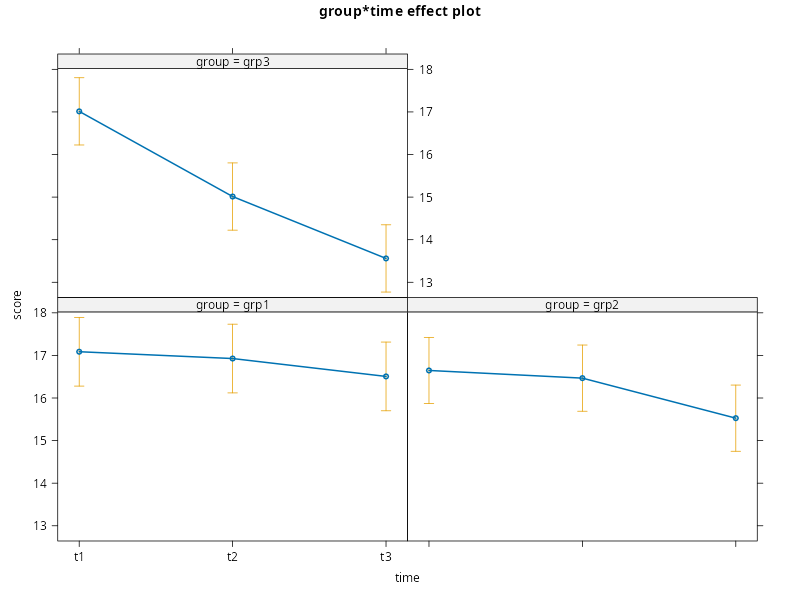

In [7]:
library('effects')
plot(effect('group:time', x.var='time', mod=anxiety.gls))

where it would appear that `grp1` shows a very subtle effect of `time`, `grp2` shows a clearer effect of `time` and `grp3` shows a very clear effect of `time`. We can also follow this effect up with some tests using `emmeans()`. Again, this follows the *same* analysis pattern we have used previously.

In [8]:
library('emmeans')
emm <- emmeans(anxiety.gls, pairwise ~ time|group, mode='asymptotic', adjust='holm')
print(emm$contrasts)

Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
group = grp1:
 contrast estimate     SE  df z.ratio p.value
 t1 - t2      0.16 0.0970 Inf   1.649  0.0992
 t1 - t3      0.58 0.1270 Inf   4.576  <.0001
 t2 - t3      0.42 0.0994 Inf   4.223  <.0001

group = grp2:
 contrast estimate     SE  df z.ratio p.value
 t1 - t2      0.18 0.0935 Inf   1.926  0.0541
 t1 - t3      1.12 0.1220 Inf   9.176  <.0001
 t2 - t3      0.94 0.0958 Inf   9.814  <.0001

group = grp3:
 contrast estimate     SE  df z.ratio p.value
 t1 - t2      2.00 0.0949 Inf  21.066  <.0001
 t1 - t3      3.45 0.1240 Inf  27.852  <.0001
 t2 - t3      1.45 0.0973 Inf  14.938  <.0001

Degrees-of-freedom method: asymptotic 
P value adjustment: holm method for 3 tests 


<div class="alert alert-block alert-info"> 
<b>ACTIVITY ?</b> Print out the results of <code>emm$emmeans</code> from the code above. This provides the standard errors for each of the cell means. The error bars in the plot above are 95% confidence intervals, which are approximately 1.96 x SE. Given this, why do the bars overlap so much, despite how significant some of the effects are? <b>HINT:</b> Compare the <code>SE</code> reported in <code>emm$emmeans</code> to the <code>SE</code> on the <i>differences</i> reported in <code>emm$contrasts</code>. Think about what you know about the variance of <i>differences</i> under dependence. How does this affect how you interpret the confidence intervals in the plots?
</div>

### Multiple Within-subject Factors
Sticking with the theme of revisiting analyses covered in last week's workshop, our second complication is when we have *multiple* within-subject factors. We will again use the `weightloss` data from `datarium` to illustrate this, which we load, convert to long-format and print for a single subject below

In [9]:
library('datarium')
library('reshape2')

data('weightloss')

# repeats and number of subjects
t <- 12 # 2 * 2 * 3
n <- 12

# reshape wide -> long
weightloss.long <- melt(weightloss,                         # wide data frame
                        id.vars=c('id','diet','exercises'), # what stays fixed?
                        variable.name="time",               # name for the new predictor
                        value.name="weight")                # name for the new outcome

weightloss.long           <- weightloss.long[order(weightloss.long$id),] # order by ID
rownames(weightloss.long) <- seq(1,n*t)                                  # fix row names

weightloss.long$id        <- as.factor(weightloss.long$id)               # id as factor
weightloss.long$diet      <- as.factor(weightloss.long$diet)             # diet as factor
weightloss.long$exercises <- as.factor(weightloss.long$exercises)        # exercises as factor
weightloss.long$time      <- as.factor(weightloss.long$time)             # time as factor

weightloss.long[weightloss.long$id == '1',]

   id diet exercises time weight
1   1   no        no   t1  10.43
2   1   no       yes   t1  11.12
3   1  yes        no   t1  10.20
4   1  yes       yes   t1  10.43
5   1   no        no   t2  13.21
6   1   no       yes   t2  12.51
7   1  yes        no   t2  12.51
8   1  yes       yes   t2  12.51
9   1   no        no   t3  11.59
10  1   no       yes   t3  15.76
11  1  yes        no   t3  14.60
12  1  yes       yes   t3  14.37

In [10]:
as.numeric(weightloss.long$time)

  [1] 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3
 [61] 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3
[121] 1 1 1 1 2 2 2 2 3 3 3 3 1 1 1 1 2 2 2 2 3 3 3 3

#### Building the Covariance Structure
Starting with the correlation, the difference with this example is that there are now 12 values for each subject, meaning that a fully unconstrained covariance structure will have $\frac{12 \times 13}{2} = 78$ parameters to estimate. This is quite a lot. 

In [ ]:
t <- as.numeric(weightloss.long$time)
weightloss.gls <- gls(weight ~ diet*exercises*time, correlation=corSymm(form= ~1|id), data=weightloss.long)

## Comparing Covariance Structures

In [ ]:
gls.mod.1 <- gls(score ~ time, correlation=corCompSymm(form= ~1|id),                                  data=selfesteem.long, method='ML') # compound symmetry + homogeneity of variance
gls.mod.2 <- gls(score ~ time, correlation=corCompSymm(form= ~1|id), weights=varIdent(form= ~1|time), data=selfesteem.long, method='ML') # compound symmetry + heterogeneity of variance
gls.mod.3 <- gls(score ~ time, correlation=    corSymm(form= ~1|id),                                  data=selfesteem.long, method='ML') # general symmetric + homogeneity of variance
gls.mod.4 <- gls(score ~ time, correlation=    corSymm(form= ~1|id), weights=varIdent(form= ~1|time), data=selfesteem.long, method='ML') # general symmetric + heterogeneity of variance

anova(gls.mod.1, gls.mod.2, gls.mod.3, gls.mod.4)

The degrees of freedom here are a count of the number of parameters that need to be estimated. As each model has the same mean structure, there in always a single *intercept* parameter and two `time` parameters. The remaining count are those associated with the covariance structure. So, we can see that `gls.mod.1` has 2 covariance parameters corresponding to the constant variance and constant correlation. Both models 2 and 3 have 4 covariance parameters, corresponding to either 1 fixed variance and 3 free correlations, or 3 free variances and 1 fixed correlation. Finally, model 4 has 6 covariance parameters, corresponding to 3 free variances and 3 free correlations.

In terms of the inferential tests, these are computed as a *likelihood ratio*, but only between models that are *nested*. In other words, one model is a subset of another. In this example, this is only true of those models that share a correlation structure. So the tests here are based on assessing whether the additional flexibility added by allowing heterogeneity of variance is warranted. The $p$-value here is also based on asymptotic theory, so we have to be quite cautious in small samples. So, for our current purpose, the $p$-value here is not so useful, but could be if we were certain we wanted a specific correlation structure and our only remaining question was whether the additional `weights=` argument was needed.

So, in terms of actually deciding between these covariance structures, we turn to model comparisons procedures using the AIC and BIC. These were explored last semester as part of the [ANOVA workshop](https://github.com/PCHN63101-Advanced-Data-Skills/Model-Comparisons-ANOVA/blob/main/ANOVA-workshop.ipynb), so it may be worth quickly revising this before going any further. ...

In terms of choosing between AIC and BIC, we will favour BIC here because BIC is more focussed on the *data-generating process* than on *prediction*. It punishes complexity much harder than AIC, meaning the data really needs to suggest a complex structure is needed for BIC to allow it. This makes BIC more favourable in terms of developing a *parsimonious* model of the data-generating process.

Focussing just on BIC, we are looking for the model with the *smallest* values of BIC. In this example, it is the model with a *compound symmetric* correlation structure and *homogeneity of variance*. However, the *absolute* value of BIC is not of importance. What matters is the *difference*. Between the model with largest and smallest BIC, the change is $\Delta\text{BIC} = 95.73 - 90.61 = 5.11$. If we look back at the interpretation guidance we gave last semester for interpreting BIC (in the [ANOVA workshop](https://github.com/PCHN63101-Advanced-Data-Skills/Model-Comparisons-ANOVA/blob/main/ANOVA-workshop.ipynb)), a change of around 5 is considered *positive evidence favouring the lower-BIC model*. This is not super strong evidence, but it is suggesting that the additional complexity is *not warranted* in order to explain the data. All other comparisons indicate *smaller* changes in BIC, meaning that although the simplest covariance structure is supported, this is not a slam-dunk by any means. In this situation, we would likely use the simplest covariance structure, but we would be aware of the fact that the evidence in support of this structure is not overwhelming and that something more complex *could* be warranted if we had more data or repeated the experiment again.

## Assumptions and Visualisations
Before we get to discussing the tricky topic of inference, we also need to consider how to check the assumptions and visualise the GLS model. Although the plain `lm()` functions allows a variety of diagnostic plots, calling `plot()` on a GLS model will only give us a single visualisation. As such, if we want something similar we need to construct these plots ourselves, with some caveats.

### Assumptions Plots
In principle, all the plots we saw previously with `lm()` can still be defined using a model fit using `gls()`. However, there are two important caveats. 

Firstly, this is true only when working with the *corrected* errors. In other words, the errors that result from *removing* the covariance structure. Technically, this means we need to assume that the covariance structure we have is *correct*, as the assumptions of the normal linear model only apply if we have managed to remove the covariance structure *perfectly*. Given that this is not going to be true under FGLS, we need to be slightly more cautious about the interpretation of these types of plots.

Secondly, *leverage* and *Cook's Distance* are not defined under GLS. It may be possible to calculate some variant that is *similar* in spirit, but this is messy and would need to be scripted manually. As such, we will skip the leverage plot and, in its place, provide a visualisation of the covariance structure as a diagnostic measure, to make sure the estimated structure is as expected.

In the drop-down below is the definition of a function called `plot.gls()` that will create some visualisations that are similar in spirit to those from the normal linear model. These are all calculated using the residuals extracted using `resid(mod, type='normalized')`, which are residuals that have been *corrected* for the covariance structure and are *standardised*.  

In [ ]:
plot.gls <- function(mod, timeseries=FALSE){

  w <- resid(mod, type="normalized")
  f <- fitted(mod)

  par(mfrow=c(2,2))

  # Residuals vs fitted
  plot(f, w, main='Residuals vs fitted')
  lines(lowess(f,w))

  # Normal Q-Q
  qqnorm(w) 
  qqline(w)
  
  # Scale-Location
  plot(f, sqrt(abs(w)), main='Scale-Location')
  lines(lowess(f,sqrt(abs(w))))

  # Either plot of the ACF, or a visualisation of the marginal covariance structure
  if (timeseries==TRUE){
    acf(w)                                   
  } else {
    V <- getVarCov(mod)
    graphics::image(as.matrix(V)[nrow(V):1, ], main='Marginal covariance structure')
  }
}

Applying this function to the results from the model with the unconstrained covariance structure gives

In [ ]:
plot.gls(gls.mod.Unconstrained )

As way of comparison, the model with the compound symmetric structure gives

In [ ]:
plot.gls(gls.mod.CompSymm)

which does appear qualitatively *worse*, thus suggesting that a more complex covariance structure provides a better model fit.